In [1]:
%load_ext autoreload
%autoreload 2
import torch 
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.manifold import Isomap, SpectralEmbedding
from sklearn.datasets import make_swiss_roll
from finsler_embedding.experiment_run import *
from finsler_embedding.disbm import *
from finsler_embedding.utils import *
from torchvision.ops import MLP
from finsler_embedding.omega import *

from scipy.ndimage import gaussian_filter
from matplotlib.colors import LightSource
from mpl_toolkits.mplot3d.axes3d import Axes3D

/home/tblanchard/phd/Finsler-Embedding/.venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
# # R = torch.sqrt((X / 1.15) ** 2 + (Y / 0.9) ** 2)



N = 3000
eps_scale = 1
m=2
def sample_data(N):
    x = torch.rand(N) * 6.4 - 3.2
    y = torch.rand(N) * 4.8 - 2.4
    X = torch.stack([x, y], dim=1)
    return X


In [3]:
class Mountain(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        x1 = x[:, 0]
        x2 = x[:, 1]
        z = (
            0.38 * torch.sin(1.15 * x1 + 0.35 * torch.cos(x2))
            * torch.cos(1.25 * x2)
            + 0.16 * torch.exp(-((x1 + 1.1) ** 2 + (x2 - 0.35) ** 2) / 0.65)
            - 0.20 * torch.exp(-((x1 - 0.85) ** 2 + (x2 + 0.55) ** 2) / 0.55)
            + 0.07 * torch.cos(0.8 * x1 * x2)
        )
        return z.unsqueeze(1)

randers_metric = SlopeMetrics(Mountain())
X = sample_data(N)
Z = Mountain()(X)

In [4]:
cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)


In [5]:
def plot_surface(X,Y,Z,ax: Axes3D,use_wireframe: bool = True):
    # Soft scientific lighting
    ls = LightSource(azdeg=315, altdeg=45)
    rgb = ls.shade(
        Z,
        cmap=cmap,
        vert_exag=0.7,
        blend_mode="soft",
    )

    if use_wireframe:
        ax.plot_wireframe(
            X, Y, Z,
            rstride=5,
            cstride=5,
            linewidth=0.5,
            antialiased=True,
            # alpha=0.96,
            color="black",
        )
    else:
        ax.plot_surface(
            X, Y, Z,
            facecolors=rgb,
            rstride=2,
            cstride=2,
            linewidth=0,
            antialiased=True,
            shade=False,
            alpha=0.8,
        )

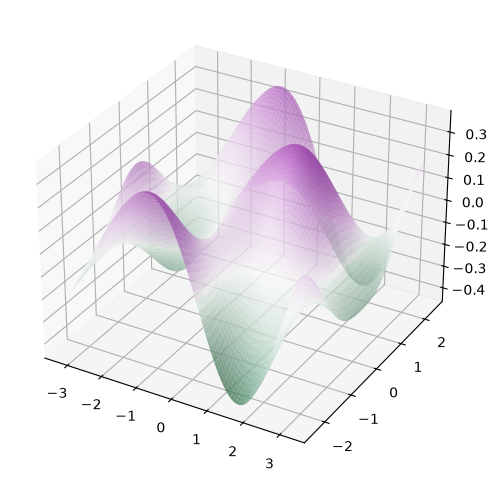

In [6]:
x_plt = torch.linspace(-3.2, 3.2, 180)
y_plt = torch.linspace(-2.4, 2.4, 150)
X_plt, Y_plt = torch.meshgrid(x_plt, y_plt, indexing='ij')

# A smooth "potato-chip" surface with a few broad features
Z_plt = (
    0.38 * torch.sin(1.15 * X_plt + 0.35 * torch.cos(Y_plt))
    * torch.cos(1.25 * Y_plt)
    + 0.16 * torch.exp(-((X_plt + 1.1) ** 2 + (Y_plt - 0.35) ** 2) / 0.65)
    - 0.20 * torch.exp(-((X_plt - 0.85) ** 2 + (Y_plt + 0.55) ** 2) / 0.55)
    + 0.07 * torch.cos(0.8 * X_plt * Y_plt)
)

fig = plt.figure(figsize=(18,6))
ax = fig.add_subplot(1, 1, 1, projection="3d")
plot_surface(X_plt.numpy(),Y_plt.numpy(),Z_plt.numpy(),ax,use_wireframe=False)

In [7]:
edges = get_knn_graph(X, n_neighbors=10,device="cpu")
LOGGER.info(f"Found {edges.shape[0]} edges in the KNN graph.")
dst_edges = construct_distance_matrix(X.requires_grad_(True), edges, randers_metric,use_approx=True)

[2026-09-21 16:30:59] - INFO - Found 34308 edges in the KNN graph.


Computing Randers distances: 100%|██████████| 344/344 [00:00<00:00, 1208.74it/s]


In [8]:
X_low = Isomap(n_components=m, n_neighbors=10).fit_transform(X.detach())
X_low = torch.from_numpy(X_low).float()
bounds = get_bounds(X_low,margin=0.3)

In [9]:
epsilon = compute_epsilon_empirical(dst_edges, scale=eps_scale)
W, _, _ = gaussian_kernel(edges, dst_edges, epsilon, N, m)
results = randers_approximation(X_low,W, epsilon, m=m)
V = results["V"]
V_normed = V / (results["c_norm_sq"].sqrt() + 1e-12).unsqueeze(1)
unit_V = V / (V.norm(dim=1, keepdim=True) + 1e-12)

In [10]:
# Sort by x coords for display
idx = torch.argsort(X_low[:, 0])
X_low_plt = X_low[idx].clone().detach()
V_plt = V[idx].clone().detach()
unit_V_plt = unit_V[idx].clone()
z_plt = Z[idx]

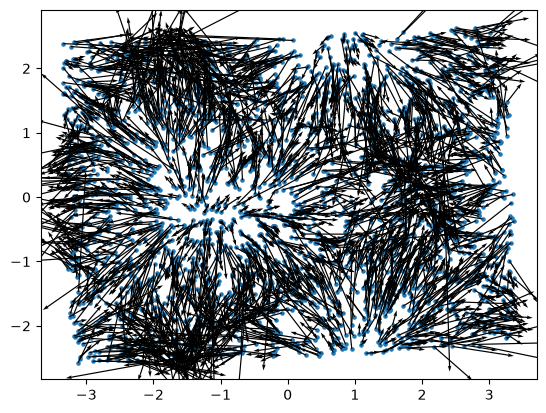

In [11]:
cbar = plt.scatter(
    X_low_plt[:, 0], X_low_plt[:, 1],s=5
)
skip=1
plt.quiver(
    X_low_plt[::skip, 0],
    X_low_plt[::skip, 1],
    # unit_V_plt[::skip, 0],
    # unit_V_plt[::skip, 1],
    V_plt[::skip, 0],
    V_plt[::skip, 1],
    color="black",
    scale=1,
    angles="xy",
    scale_units="xy",
    # alpha = results["admissible"][idx][::skip].float().sigmoid()
)

In [12]:
V = V.clone().detach()
model, loss_list = interpolate_V(X_low, V, dim=m)

  0%|          | 0/500 [00:00<?, ?it/s]

Loss: 0.0596: 100%|██████████| 500/500 [00:01<00:00, 474.09it/s]


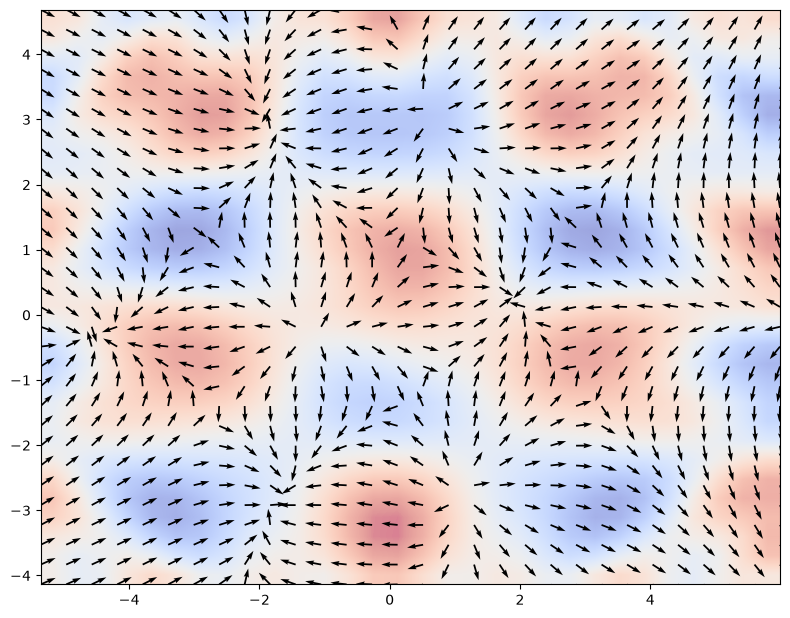

In [13]:
# Grid
x = torch.linspace(bounds[0], bounds[1], 30)
y = torch.linspace(bounds[2], bounds[3], 30)
X, Y = torch.meshgrid(x, y, indexing="ij")
grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1)
Z_grid = Mountain()(grid_points)
# grid_points += 1e-1 * torch.randn_like(grid_points)
V_grid = model(grid_points).detach()
V_grid_unit = V_grid / (V_grid.norm(dim=1, keepdim=True) + 1e-12)

plt.figure(figsize=(8, 8))
# plt.scatter(X_low[:, 0], X_low[:, 1], alpha=0.5,s=5)
# plt.scatter(
#     grid_points[:, 0],
#     grid_points[:, 1],
#     c=Z_grid,
#     cmap="coolwarm",
#     s=50,
# )

# Convert grid pts and Z_grid to a background image
grid_img = Z_grid.reshape(X.shape).numpy()
plt.imshow(
    grid_img,
    extent=(bounds[0], bounds[1], bounds[2], bounds[3]),
    origin="lower",
    cmap="coolwarm",
    alpha=0.5,
    interpolation="bilinear",
)


plt.quiver(
    grid_points[:, 0],
    grid_points[:, 1],
    V_grid_unit[:, 0],
    V_grid_unit[:, 1],
    color="black",
    scale=4,
    angles="xy",
    scale_units="xy",
)
plt.xlim(bounds[0], bounds[1])
plt.ylim(bounds[2], bounds[3])
plt.tight_layout()
# plt.axis("equal")
plt.show()